# Neuromorphic Obstacle Prediction — Data Preprocessing & SNN Training

This notebook:
1. Loads and cleans ultrasonic sensor data from an AUV.
2. Engineers temporal features (`delta`, `velocity`, `acceleration`, …).
3. Builds sliding-window sequences with a configurable **prediction horizon**.
4. Trains an **event-driven Spiking Neural Network (SNN)** using *Send-on-Delta* encoding.
5. Compares `PRED_HORIZON = 0` (current detection) vs `PRED_HORIZON = 5` (future prediction).

> **Prerequisites** — install before running:
> `pip install torch torchvision torchaudio snntorch scikit-learn pandas numpy matplotlib seaborn joblib`

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

## 2. Data Loading & Cleaning

Steps:
- Drop the CSV index artifact column (`Unnamed: 0`).
- Keep only **valid** readings (`valid == 1`).
- Remove rows recorded **before the baseline was learned** (`baseline_cm > 0`).
- Clamp filtered distance to the physically plausible range **20 – 600 cm**.

In [2]:
df = pd.read_csv("sensor.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
print("Original shape:", df.shape)

# Keep only valid readings
df = df[df["valid"] == 1].copy()

# Remove rows before baseline is learned
df = df[df["baseline_cm"] > 0].copy()

# Remove impossible distances
df = df[(df["dist_f_cm"] > 20) & (df["dist_f_cm"] <= 600)].copy()

print("After cleaning:", df.shape)
print(df.head())

Original shape: (27150, 14)
After cleaning: (23014, 14)
    session_id          run_type scenario  time_ms  sensor_id  echo_us  valid  \
37           1  C_front_far_deep     safe    31798          1     3646      1   
38           1  C_front_far_deep     safe    32080          1     3629      1   
39           1  C_front_far_deep     safe    32363          1     3657      1   
40           1  C_front_far_deep     safe    32632          1     3659      1   
41           1  C_front_far_deep     safe    32902          1     3627      1   

    dist_cm  dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  
37    269.8      267.5        268.3         120.0        140.0     0.0      0  
38    268.5      267.8        268.3         208.3        228.3     0.0      0  
39    270.6      268.5        268.3         208.3        228.3     0.0      0  
40    270.8      269.1        268.3         208.3        228.3     0.0      0  
41    268.4      268.9        268.3         208.3        

## 3. Feature Engineering

| Feature | Description |
|---------|-------------|
| `delta` | `dist_f_cm − baseline_cm` — deviation from baseline |
| `dist_to_enter` | distance to the enter-threshold |
| `dist_to_exit` | distance to the exit-threshold |
| `time_gap` | time difference between consecutive readings (per session) |
| `velocity` | rate of change of filtered distance |
| `acceleration` | rate of change of velocity |

In [3]:
# Group column for session-aware computations
group_cols = []
if "session_id" in df.columns:
    group_cols.append("session_id")

# Distance deviation from baseline
df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

# Distance to thresholds
df["dist_to_enter"] = df["dist_f_cm"] - df["enter_thr_cm"]
df["dist_to_exit"]  = df["dist_f_cm"] - df["exit_thr_cm"]

# Time gap (per session) — with fallback when no session column exists
if group_cols:
    df["time_gap"] = df.groupby(group_cols)["time_ms"].diff()
else:
    df["time_gap"] = df["time_ms"].diff()
df = df.dropna(subset=["time_gap"])

# Guard against zero time_gap (duplicate timestamps) to avoid inf/NaN
df["time_gap"] = df["time_gap"].replace(0, np.nan)
df = df.dropna(subset=["time_gap"])

# Velocity & acceleration
if group_cols:
    df["velocity"]     = df.groupby(group_cols)["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df.groupby(group_cols)["velocity"].diff()  / df["time_gap"]
else:
    df["velocity"]     = df["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df["velocity"].diff()  / df["time_gap"]
df = df.dropna(subset=["velocity", "acceleration"])

print("After feature engineering:", df.shape)
print(df.head())

After feature engineering: (22744, 20)
    session_id          run_type scenario  time_ms  sensor_id  echo_us  valid  \
40           1  C_front_far_deep     safe    32632          1     3659      1   
41           1  C_front_far_deep     safe    32902          1     3627      1   
42           1  C_front_far_deep     safe    33190          1     3656      1   
43           1  C_front_far_deep     safe    33476          1     3667      1   
44           1  C_front_far_deep     safe    33759          1     3679      1   

    dist_cm  dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  \
40    270.8      269.1        268.3         208.3        228.3     0.0      0   
41    268.4      268.9        268.3         208.3        228.3     0.0      0   
42    270.5      269.3        268.3         208.3        228.3     0.0      0   
43    271.4      269.8        268.3         208.3        228.3     0.0      0   
44    272.2      270.4        268.3         208.3        228.3     0.

## 4. Feature & Label Selection

In [4]:
feature_cols = ["time_gap", "dist_f_cm", "delta", "velocity", "acceleration"]

if "state" not in df.columns:
    df["state"] = (df["danger"] > 0).astype(int)
label_col = "state"  # always set, regardless of whether 'state' already existed

print("Features:", feature_cols)
print("Label:   ", label_col)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:  ", device)

Features: ['time_gap', 'dist_f_cm', 'delta', 'velocity', 'acceleration']
Label:    state
Device:   cpu


## 5. Send-on-Delta Encoder

Converts a continuous-valued window `(batch, time_steps, features)` into binary
ON / OFF spikes `(batch, time_steps, features × 2)`.  A spike is emitted
whenever the change from the last reference exceeds a threshold.

In [5]:
def delta_encoder(x, threshold):
    # Send-on-Delta modulation: continuous -> ON/OFF spikes.
    batch_size, time_steps, features = x.shape
    spikes = torch.zeros((batch_size, time_steps, features * 2), device=x.device)
    reference = x[:, 0, :]

    for t in range(1, time_steps):
        current_val = x[:, t, :]
        diff = current_val - reference
        on_spikes  = (diff >=  threshold).float()
        off_spikes = (diff <= -threshold).float()
        spike_mask = torch.logical_or(on_spikes > 0, off_spikes > 0).float()
        reference  = reference * (1 - spike_mask) + current_val * spike_mask
        spikes[:, t, :features] = on_spikes
        spikes[:, t, features:] = off_spikes

    return spikes

## 6. Event-Driven SNN Architecture

Three fully-connected layers interleaved with Leaky Integrate-and-Fire (LIF)
neurons.  The **input** is the spike-encoded signal from `delta_encoder`, so the
first layer has `input_size × 2` inputs.  The **output** is the membrane
potential of the final LIF layer at the last time step.

In [6]:
class EventDrivenSNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, output_size=2,
                 beta=0.9, encode_threshold=0.5):
        super().__init__()
        self.encode_threshold = encode_threshold
        self.fc1 = nn.Linear(input_size * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        spike_grad = surrogate.fast_sigmoid()
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        spk_in = delta_encoder(x, self.encode_threshold)
        time_steps = spk_in.size(1)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem3_rec = []
        for t in range(time_steps):
            cur1 = self.fc1(spk_in[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            mem3_rec.append(mem3)
        return torch.stack(mem3_rec, dim=0)  # (time_steps, batch, output_size)

## 7. Helper Functions

- **`build_windows`** — creates sliding-window sequences, returning per-window session IDs for later splitting.
- **`session_based_split`** — splits by *session*, so no session straddles train / val / test.
- **`train_one_epoch`** / **`evaluate`** — standard PyTorch train / eval loops.

In [7]:
# ───────── Window builder ─────────
def build_windows(df, feature_cols, label_col, group_cols,
                  window_size, step_size, pred_horizon):
    X, y, sids = [], [], []
    for group_key, group in df.groupby(group_cols):
        group = group.sort_values("time_ms").reset_index(drop=True)
        if len(group) < window_size + pred_horizon:
            continue
        sid = group_key if not isinstance(group_key, tuple) else group_key[0]
        for start in range(0, len(group) - window_size - pred_horizon + 1, step_size):
            end = start + window_size
            label_idx = end - 1 + pred_horizon
            X.append(group.iloc[start:end][feature_cols].values)
            y.append(group.iloc[label_idx][label_col])
            sids.append(sid)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64), np.array(sids)


# ───────── Session-based split ─────────
def session_based_split(X, y, session_ids,
                        train_ratio=0.70, val_ratio=0.15, seed=42):
    unique = np.unique(session_ids)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique)
    n = len(unique)

    # Ensure at least 1 session in val and test
    train_end = max(1, int(train_ratio * n))
    val_end   = max(train_end + 1, int((train_ratio + val_ratio) * n))
    if val_end >= n:
        val_end = n - 1          # leave at least 1 for test
    if train_end >= val_end:
        train_end = val_end - 1  # leave at least 1 for val

    train_s = set(unique[:train_end])
    val_s   = set(unique[train_end:val_end])
    test_s  = set(unique[val_end:])

    train_mask = np.isin(session_ids, list(train_s))
    val_mask   = np.isin(session_ids, list(val_s))
    test_mask  = np.isin(session_ids, list(test_s))

    return (X[train_mask], y[train_mask],
            X[val_mask],   y[val_mask],
            X[test_mask],  y[test_mask],
            train_s, val_s, test_s)


# ───────── Training loop ─────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)[-1]       # last time-step membrane potential
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        all_preds.extend(torch.argmax(output, 1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


# ───────── Evaluation loop ─────────
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)[-1]
            loss = criterion(output, yb)
            running_loss += loss.item() * xb.size(0)
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds), all_labels, all_preds

## 8. Full Training Pipeline

`run_pipeline` encapsulates windowing → splitting → scaling → training → evaluation
for a given `pred_horizon`, returning a results dict.

In [8]:
WINDOW_SIZE = 15
STEP_SIZE   = 5
NUM_EPOCHS  = 20
BATCH_SIZE  = 64

def run_pipeline(pred_horizon):
    print(f"\n{'=' * 60}")
    print(f"  PRED_HORIZON = {pred_horizon}")
    print(f"{'=' * 60}\n")

    # 1. Build windows
    X, y, sids = build_windows(df, feature_cols, label_col, group_cols,
                               WINDOW_SIZE, STEP_SIZE, pred_horizon)
    print(f"Windows: {X.shape[0]}  |  Shape: {X.shape}")
    uniq, cnts = np.unique(y, return_counts=True)
    print(f"Labels:  {dict(zip(uniq, cnts))}")

    # 2. Session-based split
    (X_tr, y_tr, X_va, y_va, X_te, y_te,
     tr_s, va_s, te_s) = session_based_split(X, y, sids)
    print(f"\nTrain sessions: {sorted(tr_s)}  ({X_tr.shape[0]} windows)")
    print(f"Val   sessions: {sorted(va_s)}  ({X_va.shape[0]} windows)")
    print(f"Test  sessions: {sorted(te_s)}  ({X_te.shape[0]} windows)")
    assert not (tr_s & va_s) and not (tr_s & te_s) and not (va_s & te_s), \
        "Session overlap!"

    # 3. Normalise (fit on train only)
    n_tr, t_dim, f_dim = X_tr.shape
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.reshape(-1, f_dim)).reshape(n_tr, t_dim, f_dim)
    X_va_s = scaler.transform(X_va.reshape(-1, f_dim)).reshape(X_va.shape)
    X_te_s = scaler.transform(X_te.reshape(-1, f_dim)).reshape(X_te.shape)

    # 4. DataLoaders
    mk = lambda x, y, shuf: DataLoader(
        TensorDataset(torch.tensor(x, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuf)
    train_dl = mk(X_tr_s, y_tr, True)
    val_dl   = mk(X_va_s, y_va, False)
    test_dl  = mk(X_te_s, y_te, False)

    # 5. Class weights
    cw = compute_class_weight("balanced",
                              classes=np.unique(y_tr), y=y_tr)
    cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
    print(f"Class weights: {cw_t}")
    criterion = nn.CrossEntropyLoss(weight=cw_t)

    # 6. Model & optimiser
    model = EventDrivenSNN(input_size=len(feature_cols),
                           hidden_size=32, output_size=2, beta=0.9).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # 7. Training loop
    hist = {"tl": [], "vl": [], "ta": [], "va": []}
    for ep in range(1, NUM_EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_dl, opt, criterion)
        vl, va, _, _ = evaluate(model, val_dl, criterion)
        hist["tl"].append(tl); hist["vl"].append(vl)
        hist["ta"].append(ta); hist["va"].append(va)
        print(f"Epoch [{ep:>2}/{NUM_EPOCHS}] "
              f"TrLoss {tl:.4f} | TrAcc {ta:.4f} | "
              f"VaLoss {vl:.4f} | VaAcc {va:.4f}")

    # 8. Test evaluation
    te_loss, te_acc, y_true, y_pred = evaluate(model, test_dl, criterion)
    print(f"\nTest Loss: {te_loss:.4f}  |  Test Acc: {te_acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Safe", "Danger"]))
    cm = confusion_matrix(y_true, y_pred)

    # 9. Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(hist["tl"], label="Train"); axes[0].plot(hist["vl"], label="Val")
    axes[0].legend(); axes[0].set_title(f"Loss  (horizon={pred_horizon})")
    axes[1].plot(hist["ta"], label="Train"); axes[1].plot(hist["va"], label="Val")
    axes[1].legend(); axes[1].set_title(f"Accuracy  (horizon={pred_horizon})")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Safe","Danger"],
                yticklabels=["Safe","Danger"], ax=axes[2])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
    axes[2].set_title(f"Confusion Matrix  (horizon={pred_horizon})")
    plt.tight_layout(); plt.show()

    return dict(pred_horizon=pred_horizon, test_acc=te_acc, test_loss=te_loss,
                y_true=y_true, y_pred=y_pred, model=model, scaler=scaler)

## 9. Run Experiments — `PRED_HORIZON` Comparison

Train and evaluate the SNN with two horizons:
| Horizon | Meaning |
|---------|---------|
| **0** | Classify the danger state at the *end* of the current window (detection). |
| **5** | Classify the danger state **5 time-steps ahead** (prediction). |


  PRED_HORIZON = 0

Windows: 4331  |  Shape: (4331, 15, 5)
Labels:  {np.int64(0): np.int64(3521), np.int64(1): np.int64(810)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77), np.int64(79), np.int64(81), np.int64(82), np.int64(85), np.int64(87), np.int64(88), np.int64

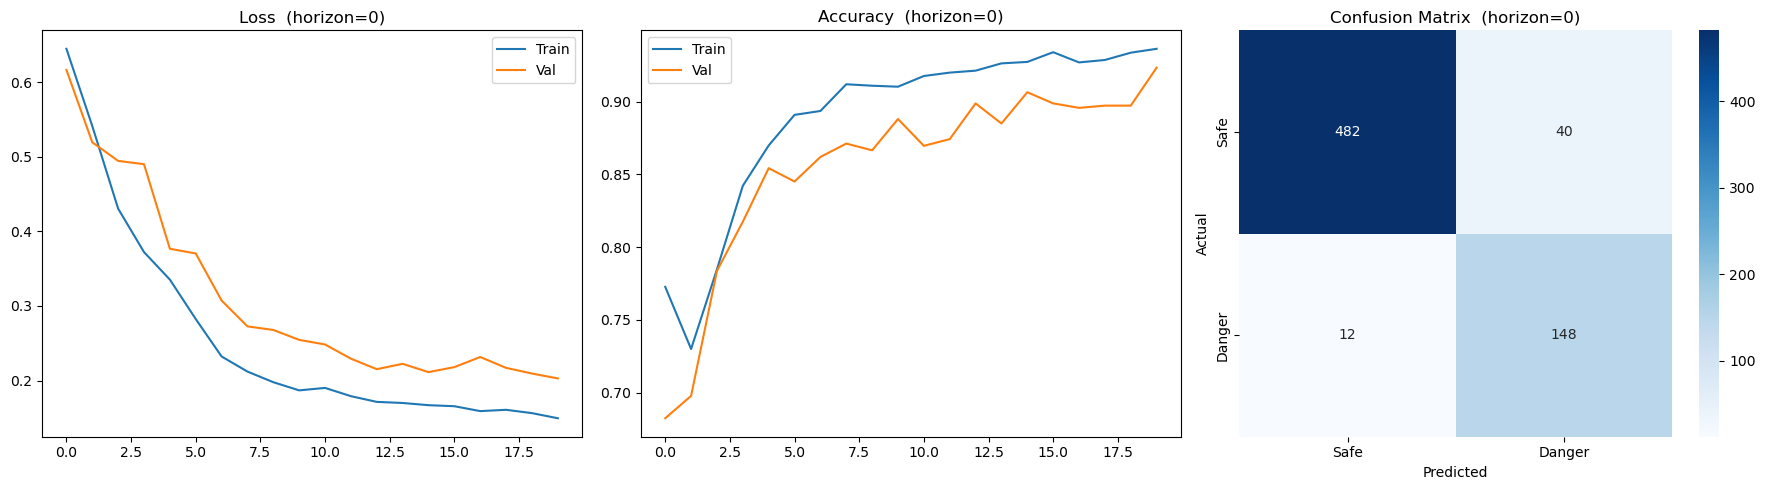


  PRED_HORIZON = 5

Windows: 4241  |  Shape: (4241, 15, 5)
Labels:  {np.int64(0): np.int64(3431), np.int64(1): np.int64(810)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77), np.int64(79), np.int64(81), np.int64(82), np.int64(85), np.int64(87), np.int64(88), np.int64

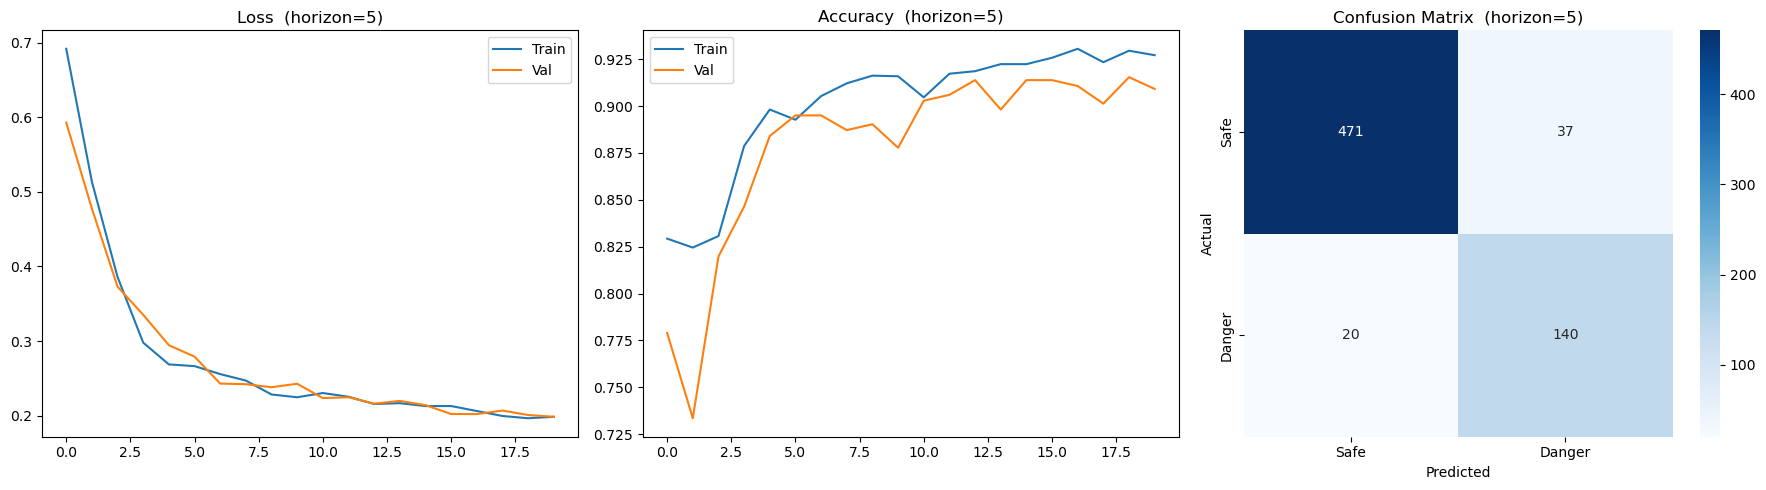

In [9]:
results = {}
for ph in [0, 5]:
    results[ph] = run_pipeline(ph)

## 10. Results Comparison

In [10]:
print(f"\n{'=' * 60}")
print(f"  PRED_HORIZON COMPARISON")
print(f"{'=' * 60}")
print(f"\n{'Metric':<25} {'HORIZON=0':>12} {'HORIZON=5':>12}")
print("-" * 50)
print(f"{'Test Accuracy':<25} {results[0]['test_acc']:>12.4f} {results[5]['test_acc']:>12.4f}")
print(f"{'Test Loss':<25} {results[0]['test_loss']:>12.4f} {results[5]['test_loss']:>12.4f}")

for ph in [0, 5]:
    rpt = classification_report(results[ph]["y_true"], results[ph]["y_pred"],
                                target_names=["Safe", "Danger"], output_dict=True)
    print(f"\nPRED_HORIZON = {ph}:")
    print(f"  Safe   — P: {rpt['Safe']['precision']:.4f}  "
          f"R: {rpt['Safe']['recall']:.4f}  F1: {rpt['Safe']['f1-score']:.4f}")
    print(f"  Danger — P: {rpt['Danger']['precision']:.4f}  "
          f"R: {rpt['Danger']['recall']:.4f}  F1: {rpt['Danger']['f1-score']:.4f}")


  PRED_HORIZON COMPARISON

Metric                       HORIZON=0    HORIZON=5
--------------------------------------------------
Test Accuracy                   0.9238       0.9147
Test Loss                       0.1896       0.2490

PRED_HORIZON = 0:
  Safe   — P: 0.9757  R: 0.9234  F1: 0.9488
  Danger — P: 0.7872  R: 0.9250  F1: 0.8506

PRED_HORIZON = 5:
  Safe   — P: 0.9593  R: 0.9272  F1: 0.9429
  Danger — P: 0.7910  R: 0.8750  F1: 0.8309


## 11. Save Model & Scaler

The checkpoint includes full architecture metadata so it can be loaded
without knowing the training configuration.

In [ ]:
best_ph = max(results, key=lambda k: results[k]["test_acc"])
print(f"Best horizon: {best_ph}  (Test Acc: {results[best_ph]['test_acc']:.4f})")

checkpoint = {
    "model_class":      "EventDrivenSNN",
    "model_state_dict": results[best_ph]["model"].state_dict(),
    "feature_cols":     feature_cols,
    "window_size":      WINDOW_SIZE,
    "step_size":        STEP_SIZE,
    "pred_horizon":     best_ph,
    "input_size":       len(feature_cols),
    "hidden_size":      32,
    "output_size":      2,
    "beta":             0.9,
    "encode_threshold": 0.5,
    "test_accuracy":    results[best_ph]["test_acc"],
}
torch.save(checkpoint, "snn_obstacle_model.pth")
joblib.dump(results[best_ph]["scaler"], "feature_scaler.pkl")
print("Saved: snn_obstacle_model.pth, feature_scaler.pkl")